# Cardiovascular Disease Prediction: Clinical ML for Early Detection

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Healthcare ML for clinical decision support in government and enterprise health systems

---

Cardiovascular disease (CVD) remains the leading cause of death globally. Early prediction using routinely collected clinical data — blood pressure, cholesterol, BMI, lifestyle factors — can flag high-risk patients *before* a cardiac event occurs.

This notebook builds a **production-grade binary classifier** to predict cardiovascular disease presence from 70,000 patient records. The framing is clinical/enterprise:
- How does this integrate with **Electronic Health Records (EHR)** and **FHIR** standards?
- What do **clinicians** need from model outputs? (Not just a score — calibrated probabilities, risk tiers, explainable features.)
- How do we handle **model fairness** across demographic groups?
- How does this align with **TGA** (Therapeutic Goods Administration) requirements for AI/ML in Australian healthcare?

**Runtime target:** < 10 minutes on Kaggle free CPU.

## 0 · Environment Setup

In [1]:
import os, warnings, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    precision_score, recall_score, brier_score_loss,
    log_loss
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (12, 6), 'axes.titlesize': 14,
    'axes.labelsize': 12, 'font.size': 11, 'figure.dpi': 100,
})

C_HEALTHY = '#2ecc71'
C_DISEASE = '#e74c3c'
C_PALETTE = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6',
             '#1abc9c', '#e67e22', '#2c3e50']

print("Environment ready ✓")

Environment ready ✓


## 1 · Data Loading & Initial Assessment

The dataset contains 70,000 patient records with 11 clinical features collected during medical examinations. The target variable `cardio` indicates presence (1) or absence (0) of cardiovascular disease.

> **Note:** The CSV uses semicolon (`;`) as separator. We auto-detect this.

In [2]:
# ── Discover and load data ──
data_path = None
all_files = []

if os.path.exists('/kaggle/input'):
    print("Scanning /kaggle/input ...\n")
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files:
            full = os.path.join(root, f)
            size_mb = os.path.getsize(full) / 1e6
            print(f"  {full}  ({size_mb:.1f} MB)")
            all_files.append(full)

    for ext in ['.csv', '.tsv', '.parquet', '.data', '.txt', '.xlsx', '.json']:
        matches = [f for f in all_files if f.lower().endswith(ext)]
        if matches:
            data_path = max(matches, key=os.path.getsize)
            break
    if data_path is None and all_files:
        data_path = max(all_files, key=os.path.getsize)
else:
    candidates = glob.glob('*.csv') + glob.glob('*.data')
    if candidates:
        data_path = candidates[0]

if data_path is None:
    raise FileNotFoundError("No data file found — did you add the dataset?")

print(f"\n>>> Loading: {data_path}")

# Auto-detect separator (this dataset uses semicolons)
with open(data_path, 'r') as f:
    first_line = f.readline()
sep = ';' if ';' in first_line else ','
print(f"Detected separator: '{sep}'")

df_raw = pd.read_csv(data_path, sep=sep)
print(f"Shape : {df_raw.shape[0]:,} rows  ×  {df_raw.shape[1]} columns")
print(f"Memory: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df_raw.head()

Scanning /kaggle/input ...

  /kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv  (2.9 MB)

>>> Loading: /kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv
Detected separator: ';'
Shape : 70,000 rows  ×  13 columns
Memory: 7.3 MB


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
# Schema overview
info_df = pd.DataFrame({
    'dtype': df_raw.dtypes,
    'non_null': df_raw.notnull().sum(),
    'null_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'nunique': df_raw.nunique(),
    'min': df_raw.min(numeric_only=False),
    'max': df_raw.max(numeric_only=False),
})
info_df

,dtype,non_null,null_pct,nunique,min,max
id,int64,70000,0.0,70000,0.0,99999.0
age,int64,70000,0.0,8076,10798.0,23713.0
gender,int64,70000,0.0,2,1.0,2.0
height,int64,70000,0.0,109,55.0,250.0
weight,float64,70000,0.0,287,10.0,200.0
ap_hi,int64,70000,0.0,153,-150.0,16020.0
ap_lo,int64,70000,0.0,157,-70.0,11000.0
cholesterol,int64,70000,0.0,3,1.0,3.0
gluc,int64,70000,0.0,3,1.0,3.0
smoke,int64,70000,0.0,2,0.0,1.0


In [4]:
# Identify target
TARGET = 'cardio' if 'cardio' in df_raw.columns else df_raw.columns[-1]
print(f"Target: '{TARGET}'")
print(f"\nClass distribution:")
vc = df_raw[TARGET].value_counts()
for cls, cnt in vc.items():
    label = 'Healthy' if cls == 0 else 'CVD Present'
    print(f"  {cls} ({label}): {cnt:,} ({cnt/len(df_raw)*100:.1f}%)")
print(f"\nBalance ratio: {vc.min()/vc.max():.3f}")

Target: 'cardio'

Class distribution:
  0 (Healthy): 35,021 (50.0%)
  1 (CVD Present): 34,979 (50.0%)

Balance ratio: 0.999


## 2 · Exploratory Data Analysis

Understanding the clinical profile of CVD patients is essential before modelling. Key questions:
- **Demographics:** What age/gender distribution do we see?
- **Clinical measurements:** How do blood pressure, cholesterol, and BMI differ between groups?
- **Lifestyle factors:** Do smoking, alcohol, and physical activity show clear associations?
- **Data quality:** Are there outliers (e.g., impossible blood pressure values)?

In [5]:
# 2·1 — Data cleaning: handle known issues with this dataset
# Age is in days → convert to years
if 'age' in df_raw.columns and df_raw['age'].max() > 200:
    df_raw['age_years'] = (df_raw['age'] / 365.25).round(1)
    print(f"Converted age from days to years: range [{df_raw['age_years'].min():.0f}, {df_raw['age_years'].max():.0f}]")

# Blood pressure outliers (physiologically impossible values)
if 'ap_hi' in df_raw.columns:
    before = len(df_raw)
    # Remove extreme outliers
    df_clean = df_raw[
        (df_raw['ap_hi'] > 60) & (df_raw['ap_hi'] < 250) &
        (df_raw['ap_lo'] > 30) & (df_raw['ap_lo'] < 200) &
        (df_raw['ap_hi'] > df_raw['ap_lo'])  # systolic must be > diastolic
    ].copy()
    removed = before - len(df_clean)
    print(f"Removed {removed:,} rows with physiologically impossible BP values ({removed/before*100:.1f}%)")
else:
    df_clean = df_raw.copy()

# Remove height/weight outliers
if 'height' in df_clean.columns:
    df_clean = df_clean[(df_clean['height'] > 100) & (df_clean['height'] < 220)]
if 'weight' in df_clean.columns:
    df_clean = df_clean[(df_clean['weight'] > 30) & (df_clean['weight'] < 250)]

print(f"\nClean dataset: {len(df_clean):,} rows ({len(df_clean)/len(df_raw)*100:.1f}% retained)")

# Drop duplicates
n_dup = df_clean.duplicated().sum()
if n_dup > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Dropped {n_dup:,} duplicate rows → {len(df_clean):,} remaining")

Converted age from days to years: range [30, 65]
Removed 1,329 rows with physiologically impossible BP values (1.9%)

Clean dataset: 68,632 rows (98.0% retained)


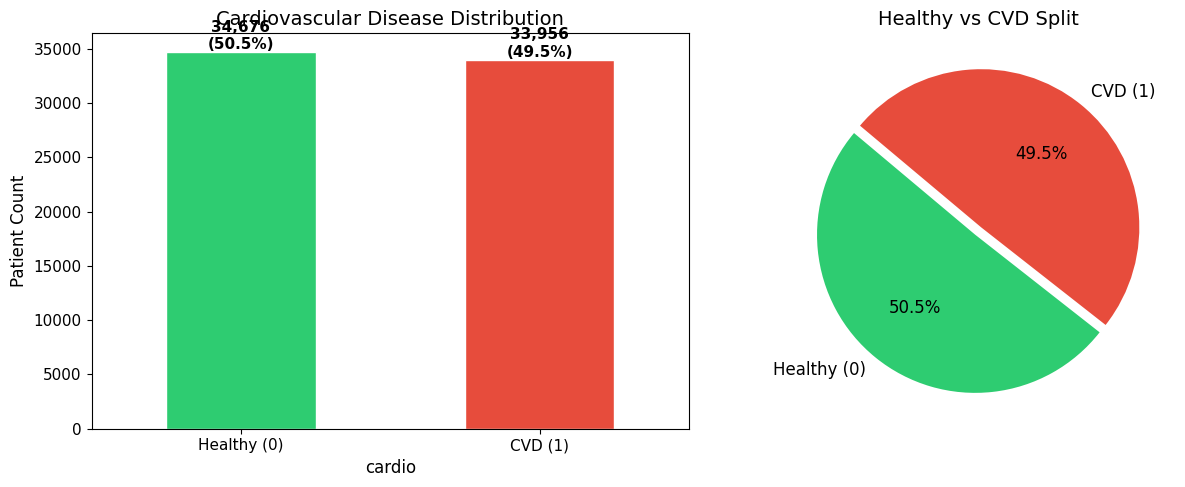

In [6]:
# 2·2 — Class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

vc = df_clean[TARGET].value_counts()
labels = ['Healthy (0)', 'CVD (1)']
colors = [C_HEALTHY, C_DISEASE]

vc.plot.bar(ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Cardiovascular Disease Distribution')
axes[0].set_ylabel('Patient Count')
axes[0].set_xticklabels(labels, rotation=0)
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 300, f'{v:,}\n({v/len(df_clean)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].pie(vc, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=140, textprops={'fontsize': 12}, explode=[0.03, 0.03])
axes[1].set_title('Healthy vs CVD Split')

plt.tight_layout()
plt.show()

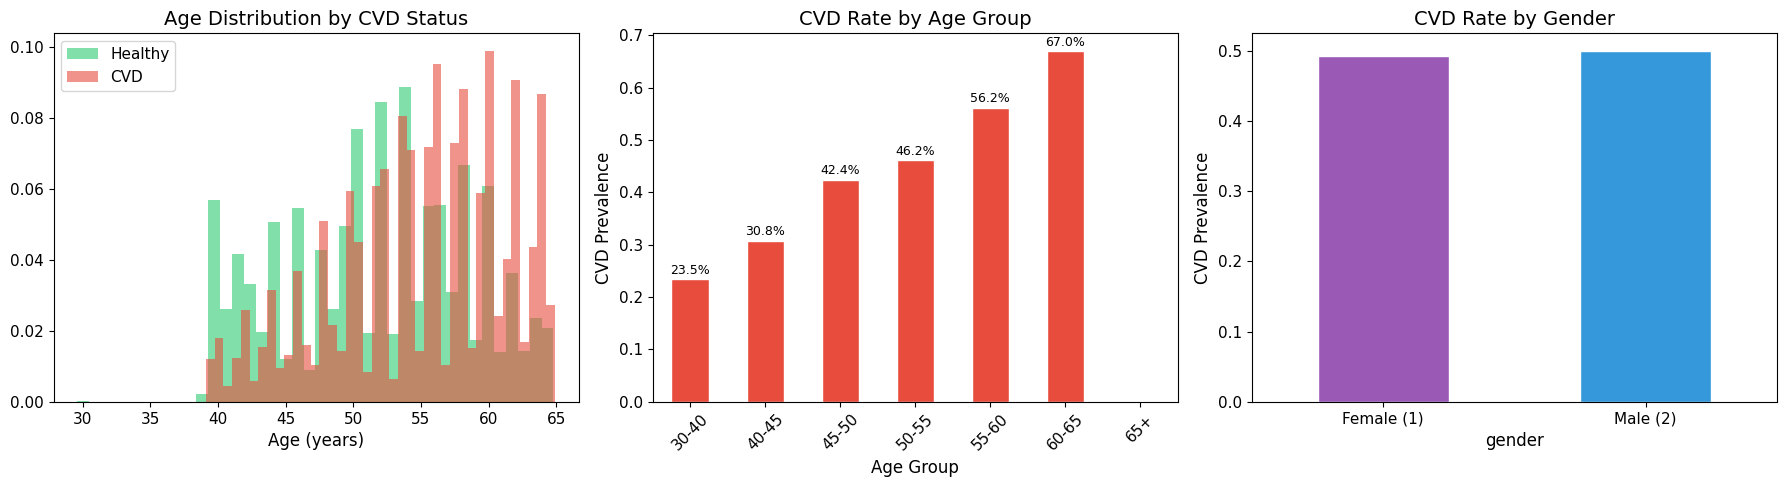

In [7]:
# 2·3 — Age & gender analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

age_col = 'age_years' if 'age_years' in df_clean.columns else 'age'

# Age distribution by CVD status
for status, color, label in [(0, C_HEALTHY, 'Healthy'), (1, C_DISEASE, 'CVD')]:
    subset = df_clean[df_clean[TARGET] == status][age_col]
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
axes[0].set_title('Age Distribution by CVD Status')
axes[0].set_xlabel('Age (years)' if 'years' in age_col else 'Age')
axes[0].legend()

# CVD rate by age group
if 'age_years' in df_clean.columns:
    df_clean['age_group'] = pd.cut(df_clean['age_years'], bins=[29, 40, 45, 50, 55, 60, 65, 100],
                                    labels=['30-40', '40-45', '45-50', '50-55', '55-60', '60-65', '65+'])
    cvd_by_age = df_clean.groupby('age_group')[TARGET].mean()
    cvd_by_age.plot.bar(ax=axes[1], color=[C_DISEASE], edgecolor='white')
    axes[1].set_title('CVD Rate by Age Group')
    axes[1].set_ylabel('CVD Prevalence')
    axes[1].set_xlabel('Age Group')
    axes[1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(cvd_by_age.values):
        axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=9)

# Gender analysis
if 'gender' in df_clean.columns:
    gender_cvd = df_clean.groupby('gender')[TARGET].mean()
    gender_labels = ['Female (1)', 'Male (2)'] if set(df_clean['gender'].unique()) == {1, 2} else [str(g) for g in gender_cvd.index]
    gender_cvd.plot.bar(ax=axes[2], color=['#9b59b6', '#3498db'], edgecolor='white')
    axes[2].set_title('CVD Rate by Gender')
    axes[2].set_ylabel('CVD Prevalence')
    axes[2].set_xticklabels(gender_labels, rotation=0)

plt.tight_layout()
plt.show()

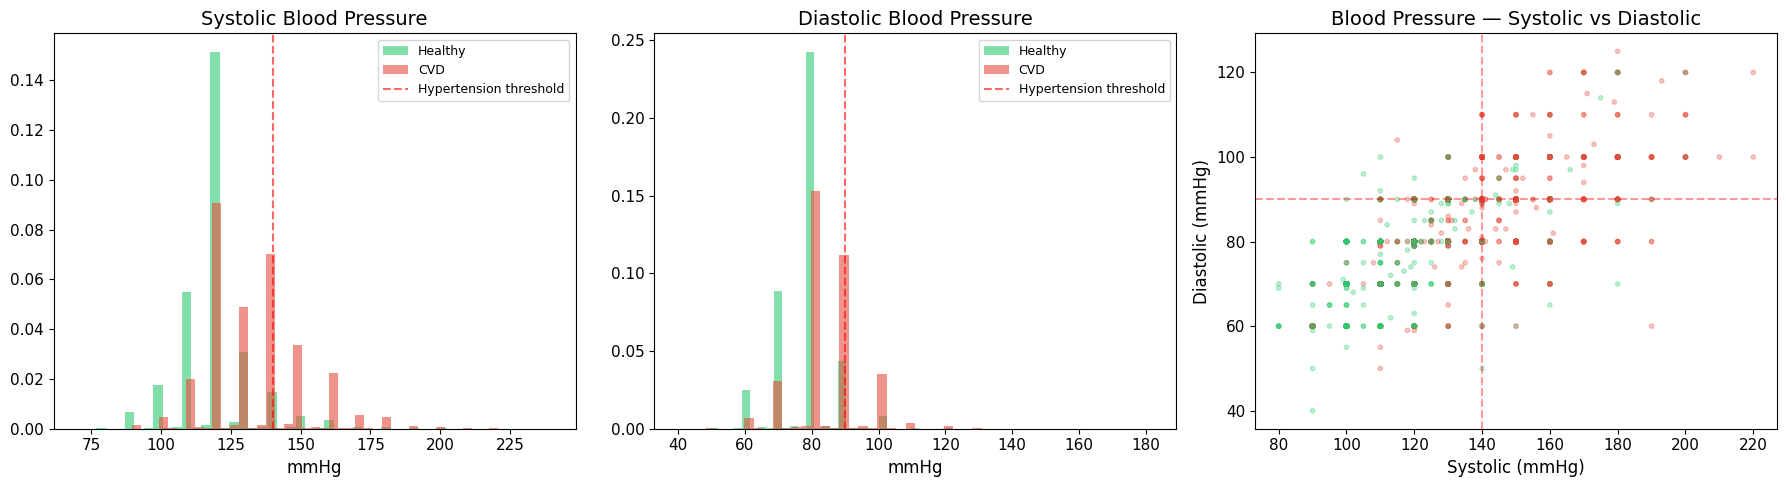

In [8]:
# 2·4 — Blood pressure analysis
if 'ap_hi' in df_clean.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Systolic BP by CVD status
    for status, color, label in [(0, C_HEALTHY, 'Healthy'), (1, C_DISEASE, 'CVD')]:
        subset = df_clean[df_clean[TARGET] == status]['ap_hi']
        axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
    axes[0].set_title('Systolic Blood Pressure')
    axes[0].set_xlabel('mmHg')
    axes[0].axvline(x=140, color='red', linestyle='--', alpha=0.6, label='Hypertension threshold')
    axes[0].legend(fontsize=9)

    # Diastolic BP
    for status, color, label in [(0, C_HEALTHY, 'Healthy'), (1, C_DISEASE, 'CVD')]:
        subset = df_clean[df_clean[TARGET] == status]['ap_lo']
        axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
    axes[1].set_title('Diastolic Blood Pressure')
    axes[1].set_xlabel('mmHg')
    axes[1].axvline(x=90, color='red', linestyle='--', alpha=0.6, label='Hypertension threshold')
    axes[1].legend(fontsize=9)

    # BP scatter
    sample = df_clean.sample(min(5000, len(df_clean)), random_state=42)
    scatter_colors = [C_HEALTHY if x == 0 else C_DISEASE for x in sample[TARGET]]
    axes[2].scatter(sample['ap_hi'], sample['ap_lo'], c=scatter_colors, alpha=0.3, s=10)
    axes[2].set_title('Blood Pressure — Systolic vs Diastolic')
    axes[2].set_xlabel('Systolic (mmHg)')
    axes[2].set_ylabel('Diastolic (mmHg)')
    axes[2].axvline(x=140, color='red', linestyle='--', alpha=0.4)
    axes[2].axhline(y=90, color='red', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

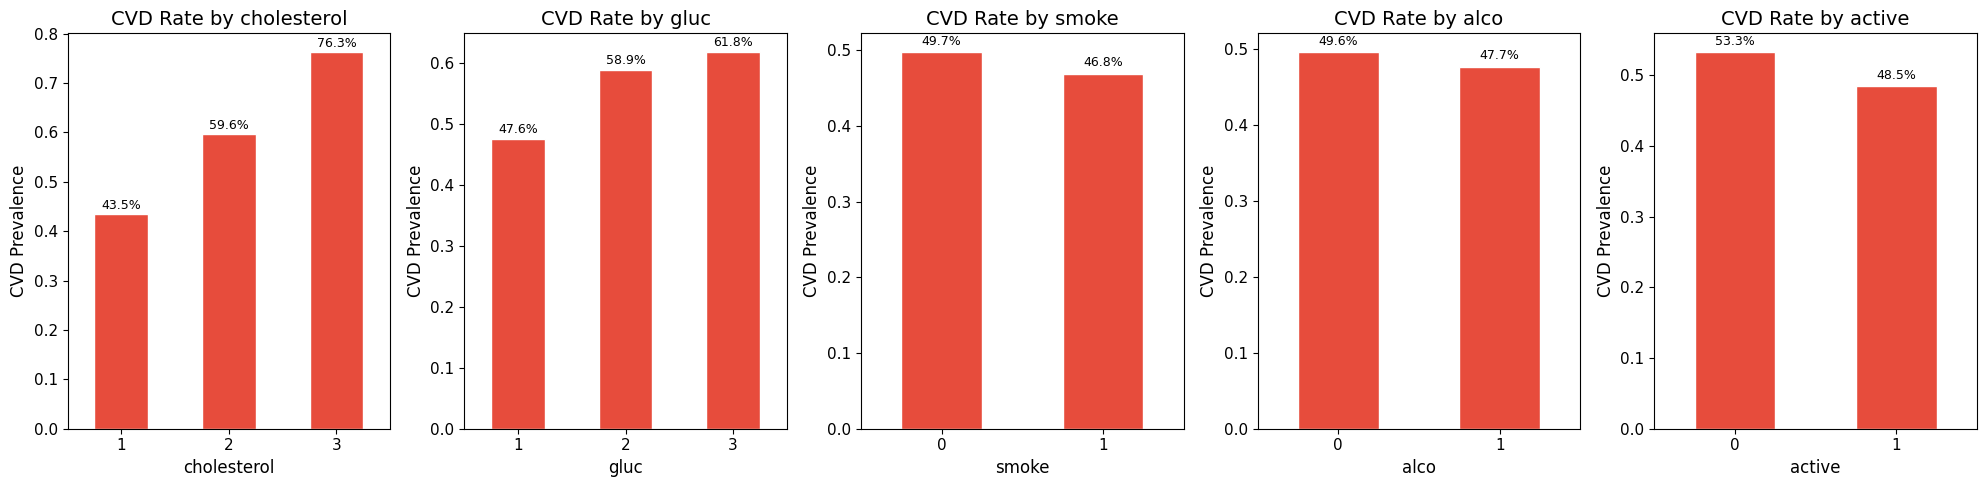

Clinical interpretation:
  Cholesterol: Normal(1)=43.5% → Above Normal(2)=59.6% → Well Above(3)=76.3% CVD rate
  Smoking: Non-smoker=49.7% vs Smoker=46.8% CVD rate
  Physical activity: Inactive=53.3% vs Active=48.5% CVD rate


In [9]:
# 2·5 — Lifestyle factors & categorical features
cat_features = ['cholesterol', 'gluc', 'smoke', 'alco', 'active']
cat_available = [c for c in cat_features if c in df_clean.columns]

if cat_available:
    fig, axes = plt.subplots(1, len(cat_available), figsize=(4*len(cat_available), 5))
    if len(cat_available) == 1:
        axes = [axes]

    for ax, col in zip(axes, cat_available):
        ct = df_clean.groupby(col)[TARGET].mean()
        ct.plot.bar(ax=ax, color=C_DISEASE, edgecolor='white')
        ax.set_title(f'CVD Rate by {col}')
        ax.set_ylabel('CVD Prevalence')
        ax.tick_params(axis='x', rotation=0)
        for i, v in enumerate(ct.values):
            ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Interpretation
    print("Clinical interpretation:")
    if 'cholesterol' in cat_available:
        chol_cvd = df_clean.groupby('cholesterol')[TARGET].mean()
        print(f"  Cholesterol: Normal(1)={chol_cvd.get(1,0):.1%} → Above Normal(2)={chol_cvd.get(2,0):.1%} → Well Above(3)={chol_cvd.get(3,0):.1%} CVD rate")
    if 'smoke' in cat_available:
        smoke_cvd = df_clean.groupby('smoke')[TARGET].mean()
        print(f"  Smoking: Non-smoker={smoke_cvd.get(0,0):.1%} vs Smoker={smoke_cvd.get(1,0):.1%} CVD rate")
    if 'active' in cat_available:
        active_cvd = df_clean.groupby('active')[TARGET].mean()
        print(f"  Physical activity: Inactive={active_cvd.get(0,0):.1%} vs Active={active_cvd.get(1,0):.1%} CVD rate")

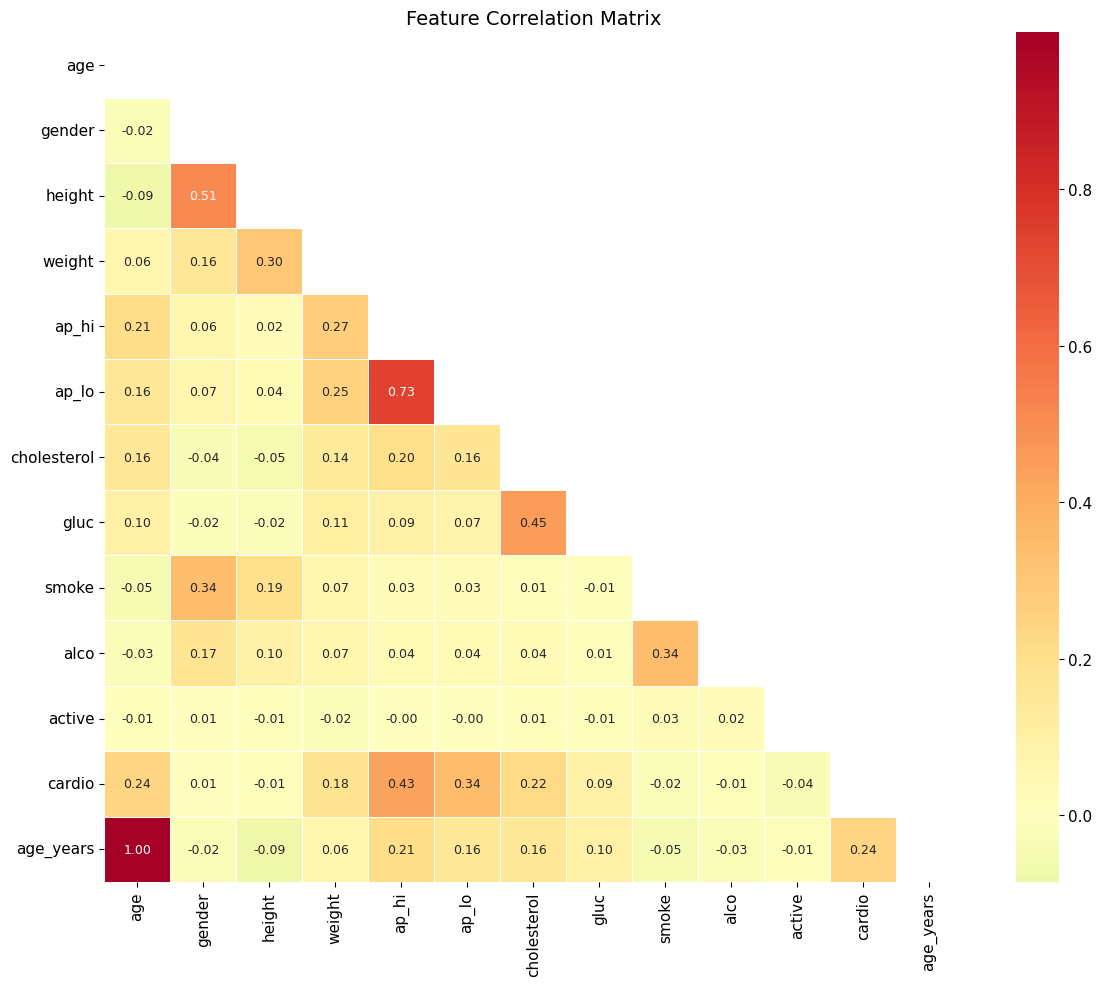

Top feature correlations with cardio:
  ap_hi               : 0.428
  ap_lo               : 0.340
  age                 : 0.239
  age_years           : 0.239
  cholesterol         : 0.221
  weight              : 0.180
  gluc                : 0.090
  active              : 0.038
  smoke               : 0.016
  height              : 0.012
  alco                : 0.009
  gender              : 0.007


In [10]:
# 2·6 — Correlation heatmap
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'id' in num_cols:
    num_cols.remove('id')

fig, ax = plt.subplots(figsize=(12, 10))
corr = df_clean[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn_r', center=0,
            linewidths=0.5, ax=ax, fmt='.2f',
            annot=True, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print(f"Top feature correlations with {TARGET}:")
for feat, val in target_corr.items():
    print(f"  {feat:20s}: {val:.3f}")

## 3 · Feature Engineering & Preprocessing

Clinical domain knowledge drives our feature engineering:
- **BMI** (Body Mass Index) — a standard clinical risk factor
- **Pulse pressure** — the gap between systolic and diastolic BP, a strong CVD indicator
- **MAP** (Mean Arterial Pressure) — used clinically to assess organ perfusion
- **BP categories** — mapped to standard clinical hypertension stages
- Age already converted from days to years in the cleaning step

In [11]:
df = df_clean.copy()

# ── BMI ──
if 'height' in df.columns and 'weight' in df.columns:
    df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
    print(f"Created 'bmi': mean={df['bmi'].mean():.1f}, range=[{df['bmi'].min():.1f}, {df['bmi'].max():.1f}]")

    # BMI categories (WHO classification)
    df['bmi_cat'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 999],
                           labels=[0, 1, 2, 3]).cat.codes.astype(int)
    df.loc[df['bmi_cat'] < 0, 'bmi_cat'] = 1  # fill any edge cases with 'Normal'
    print(f"Created 'bmi_cat': Underweight(0), Normal(1), Overweight(2), Obese(3)")

# ── Blood pressure features ──
if 'ap_hi' in df.columns:
    df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
    print(f"Created 'pulse_pressure': mean={df['pulse_pressure'].mean():.1f}")

    df['map'] = df['ap_lo'] + (df['pulse_pressure'] / 3)
    print(f"Created 'map' (Mean Arterial Pressure): mean={df['map'].mean():.1f}")

    # Hypertension stage (AHA guidelines)
    conditions = [
        (df['ap_hi'] < 120) & (df['ap_lo'] < 80),
        (df['ap_hi'].between(120, 129)) & (df['ap_lo'] < 80),
        (df['ap_hi'].between(130, 139)) | (df['ap_lo'].between(80, 89)),
        (df['ap_hi'] >= 140) | (df['ap_lo'] >= 90),
    ]
    df['bp_stage'] = np.select(conditions, [0, 1, 2, 3], default=3)
    print(f"Created 'bp_stage': Normal(0), Elevated(1), Stage1(2), Stage2(3)")

# ── Age interaction ──
age_col = 'age_years' if 'age_years' in df.columns else 'age'
if 'ap_hi' in df.columns:
    df['age_bp_interaction'] = df[age_col] * df['ap_hi']
    print(f"Created 'age_bp_interaction'")
if 'cholesterol' in df.columns:
    df['age_chol_interaction'] = df[age_col] * df['cholesterol']
    print(f"Created 'age_chol_interaction'")

print(f"\nTotal features: {df.shape[1]}")

Created 'bmi': mean=27.5, range=[10.7, 152.6]
Created 'bmi_cat': Underweight(0), Normal(1), Overweight(2), Obese(3)
Created 'pulse_pressure': mean=45.4
Created 'map' (Mean Arterial Pressure): mean=96.4
Created 'bp_stage': Normal(0), Elevated(1), Stage1(2), Stage2(3)
Created 'age_bp_interaction'
Created 'age_chol_interaction'

Total features: 22


In [12]:
# ── Prepare X, y ──
drop_cols = [TARGET]
if 'id' in df.columns:
    drop_cols.append('id')
if 'age' in df.columns and 'age_years' in df.columns:
    drop_cols.append('age')  # keep age_years, drop age in days
if 'age_group' in df.columns:
    drop_cols.append('age_group')  # categorical, not for modelling

feature_cols = [c for c in df.columns if c not in drop_cols]
X_all = df[feature_cols].copy()
y_all = df[TARGET].values

# Scale
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_all), columns=feature_cols, index=X_all.index)

print(f"X shape: {X_scaled.shape}")
print(f"y: {(y_all==0).sum():,} healthy  |  {(y_all==1).sum():,} CVD  |  CVD rate: {y_all.mean():.1%}")
print(f"Features: {feature_cols}")

X shape: (68632, 18)
y: 34,676 healthy  |  33,956 CVD  |  CVD rate: 49.5%
Features: ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi', 'bmi_cat', 'pulse_pressure', 'map', 'bp_stage', 'age_bp_interaction', 'age_chol_interaction']


## 4 · Clinical Risk Factor Analysis

Before modelling, we profile the key risk factors. This is what a clinician would present at a case conference — it builds trust in the model and validates that it's learning real clinical signals, not noise.

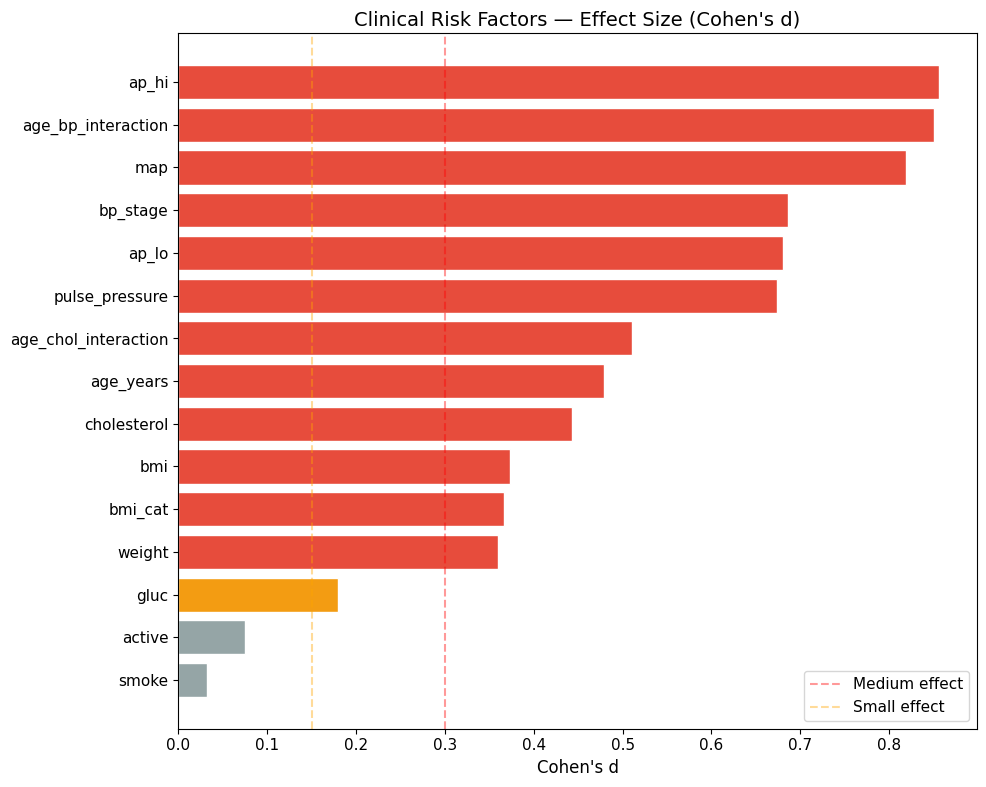

Top clinical risk factors (by effect size):
  ap_hi                    : d=0.856  CVD mean ↑ 11.9% vs healthy
  age_bp_interaction       : d=0.850  CVD mean ↑ 18.7% vs healthy
  map                      : d=0.819  CVD mean ↑ 9.8% vs healthy
  bp_stage                 : d=0.686  CVD mean ↑ 39.0% vs healthy
  ap_lo                    : d=0.680  CVD mean ↑ 8.2% vs healthy
  pulse_pressure           : d=0.674  CVD mean ↑ 19.0% vs healthy
  age_chol_interaction     : d=0.510  CVD mean ↑ 32.3% vs healthy
  age_years                : d=0.479  CVD mean ↑ 6.3% vs healthy


In [13]:
# 4·1 — Risk factor profiles
healthy = df[df[TARGET] == 0]
cvd = df[df[TARGET] == 1]

risk_factors = []
for col in feature_cols:
    rf = {
        'feature': col,
        'healthy_mean': healthy[col].mean(),
        'cvd_mean': cvd[col].mean(),
        'diff_pct': ((cvd[col].mean() - healthy[col].mean()) / (healthy[col].mean() + 1e-9)) * 100,
        'cohen_d': abs(cvd[col].mean() - healthy[col].mean()) / (df[col].std() + 1e-9)
    }
    risk_factors.append(rf)

rf_df = pd.DataFrame(risk_factors).sort_values('cohen_d', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_rf = rf_df.head(15)
colors_rf = ['#e74c3c' if d > 0.3 else '#f39c12' if d > 0.15 else '#95a5a6'
             for d in top_rf['cohen_d']]
ax.barh(range(len(top_rf)), top_rf['cohen_d'].values, color=colors_rf, edgecolor='white')
ax.set_yticks(range(len(top_rf)))
ax.set_yticklabels(top_rf['feature'].values)
ax.invert_yaxis()
ax.set_title("Clinical Risk Factors — Effect Size (Cohen's d)")
ax.set_xlabel("Cohen's d")
ax.axvline(x=0.3, color='red', linestyle='--', alpha=0.4, label='Medium effect')
ax.axvline(x=0.15, color='orange', linestyle='--', alpha=0.4, label='Small effect')
ax.legend()
plt.tight_layout()
plt.show()

print("Top clinical risk factors (by effect size):")
for _, row in rf_df.head(8).iterrows():
    direction = "↑" if row['diff_pct'] > 0 else "↓"
    print(f"  {row['feature']:25s}: d={row['cohen_d']:.3f}  CVD mean {direction} {abs(row['diff_pct']):.1f}% vs healthy")

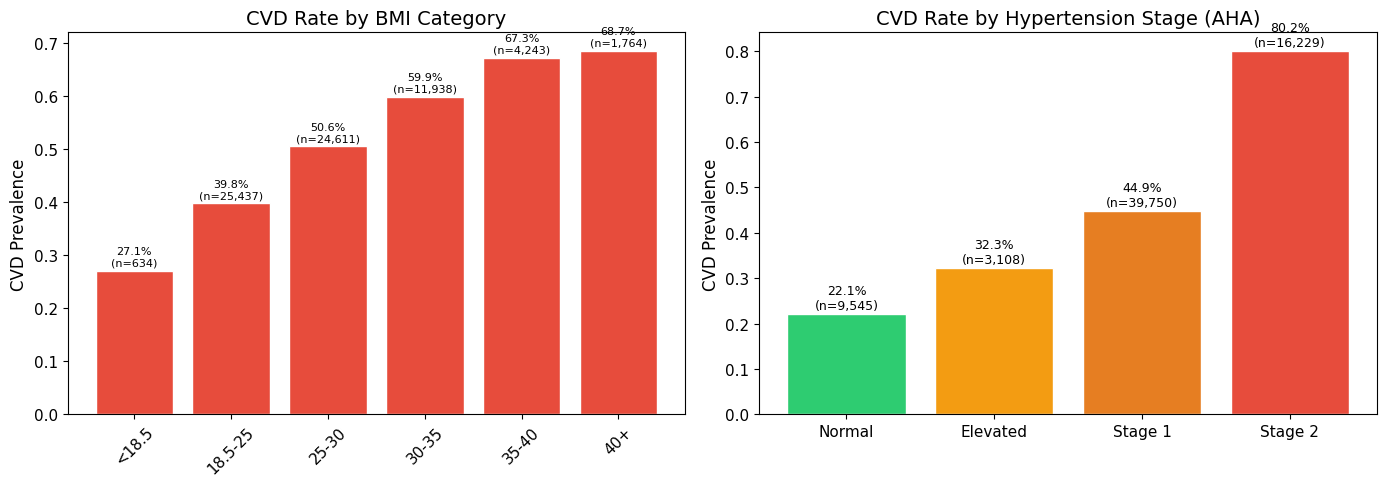

In [14]:
# 4·2 — BMI and BP interaction with CVD
if 'bmi' in df.columns and 'ap_hi' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # BMI vs CVD rate
    bmi_bins = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 35, 40, 100],
                      labels=['<18.5', '18.5-25', '25-30', '30-35', '35-40', '40+'])
    bmi_cvd = df.groupby(bmi_bins)[TARGET].agg(['mean', 'count'])
    axes[0].bar(range(len(bmi_cvd)), bmi_cvd['mean'], color=C_DISEASE, edgecolor='white')
    axes[0].set_xticks(range(len(bmi_cvd)))
    axes[0].set_xticklabels(bmi_cvd.index, rotation=45)
    axes[0].set_title('CVD Rate by BMI Category')
    axes[0].set_ylabel('CVD Prevalence')
    for i, (rate, count) in enumerate(zip(bmi_cvd['mean'], bmi_cvd['count'])):
        axes[0].text(i, rate + 0.01, f'{rate:.1%}\n(n={count:,})', ha='center', fontsize=8)

    # BP stage vs CVD rate
    if 'bp_stage' in df.columns:
        bp_labels = ['Normal', 'Elevated', 'Stage 1', 'Stage 2']
        bp_cvd = df.groupby('bp_stage')[TARGET].agg(['mean', 'count'])
        axes[1].bar(range(len(bp_cvd)), bp_cvd['mean'],
                    color=[C_HEALTHY, '#f39c12', '#e67e22', C_DISEASE], edgecolor='white')
        axes[1].set_xticks(range(len(bp_cvd)))
        axes[1].set_xticklabels(bp_labels)
        axes[1].set_title('CVD Rate by Hypertension Stage (AHA)')
        axes[1].set_ylabel('CVD Prevalence')
        for i, (rate, count) in enumerate(zip(bp_cvd['mean'], bp_cvd['count'])):
            axes[1].text(i, rate + 0.01, f'{rate:.1%}\n(n={count:,})', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

## 5 · Model Training & Comparison

Four classifiers, each with a clinical deployment rationale:

| Model | Clinical use case |
|---|---|
| **Logistic Regression** | Gold standard for clinical risk scores; fully interpretable coefficients |
| **Random Forest** | Robust ensemble; handles non-linear risk interactions |
| **XGBoost** | Highest accuracy for tabular clinical data |
| **LightGBM** | Fast inference for real-time EHR integration |

**CV strategy:** 3-fold stratified · **Metrics:** AUC, F1, precision, recall, Brier score (calibration)

In [15]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=500, class_weight='balanced', solver='lbfgs',
        n_jobs=-1, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        n_jobs=-1, random_state=42, max_depth=12),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        tree_method='hist', eval_metric='logloss',
        use_label_encoder=False, n_jobs=-1, random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100, max_depth=8, learning_rate=0.1,
        class_weight='balanced', n_jobs=-1, random_state=42, verbose=-1),
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
print(f"Training on {len(X_scaled):,} rows × {X_scaled.shape[1]} features")
print(f"3-fold CV with {len(models)} models\n")

Training on 68,632 rows × 18 features
3-fold CV with 4 models



In [16]:
results = {}
oof_probs = {}

for name, model in models.items():
    print(f"{'='*55}")
    print(f"  {name}")
    t0 = time.time()

    oof_prob = np.zeros(len(y_all))
    oof_pred = np.zeros(len(y_all))

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_scaled, y_all)):
        model.fit(X_scaled.iloc[tr_idx], y_all[tr_idx])
        prob = model.predict_proba(X_scaled.iloc[va_idx])[:, 1]
        oof_prob[va_idx] = prob
        oof_pred[va_idx] = (prob >= 0.5).astype(int)

        f1_val = f1_score(y_all[va_idx], oof_pred[va_idx].astype(int))
        print(f"    Fold {fold+1}: F1={f1_val:.4f}")

    elapsed = time.time() - t0
    oof_probs[name] = oof_prob

    results[name] = {
        'accuracy': accuracy_score(y_all, oof_pred),
        'precision': precision_score(y_all, oof_pred),
        'recall': recall_score(y_all, oof_pred),
        'f1': f1_score(y_all, oof_pred),
        'f1_macro': f1_score(y_all, oof_pred, average='macro'),
        'f1_weighted': f1_score(y_all, oof_pred, average='weighted'),
        'roc_auc': roc_auc_score(y_all, oof_prob),
        'brier': brier_score_loss(y_all, oof_prob),
        'time_sec': elapsed,
    }
    print(f"    OOF:  AUC={results[name]['roc_auc']:.4f}  F1={results[name]['f1']:.4f}  "
          f"Brier={results[name]['brier']:.4f}  ({elapsed:.1f}s)")

res_df = pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)
print("\n✓ All models trained")
res_df.round(4)

  Logistic Regression
    Fold 1: F1=0.7197
    Fold 2: F1=0.7252
    Fold 3: F1=0.7202
    OOF:  AUC=0.7945  F1=0.7217  Brier=0.1855  (5.1s)
  Random Forest
    Fold 1: F1=0.7152
    Fold 2: F1=0.7202
    Fold 3: F1=0.7188
    OOF:  AUC=0.7990  F1=0.7181  Brier=0.1816  (7.2s)
  XGBoost
    Fold 1: F1=0.7165
    Fold 2: F1=0.7204
    Fold 3: F1=0.7215
    OOF:  AUC=0.8001  F1=0.7195  Brier=0.1811  (1.3s)
  LightGBM
    Fold 1: F1=0.7184
    Fold 2: F1=0.7229
    Fold 3: F1=0.7233
    OOF:  AUC=0.8004  F1=0.7216  Brier=0.1809  (1.5s)

✓ All models trained


,accuracy,precision,recall,f1,f1_macro,f1_weighted,roc_auc,brier,time_sec
LightGBM,0.7342,0.7490,0.6960,0.7216,0.7337,0.7338,0.8004,0.1809,1.4533
XGBoost,0.7344,0.7535,0.6884,0.7195,0.7336,0.7338,0.8001,0.1811,1.3327
Random Forest,0.7331,0.7522,0.6869,0.7181,0.7324,0.7325,0.7990,0.1816,7.1640
Logistic Regression,0.7308,0.7386,0.7056,0.7217,0.7305,0.7306,0.7945,0.1855,5.1479


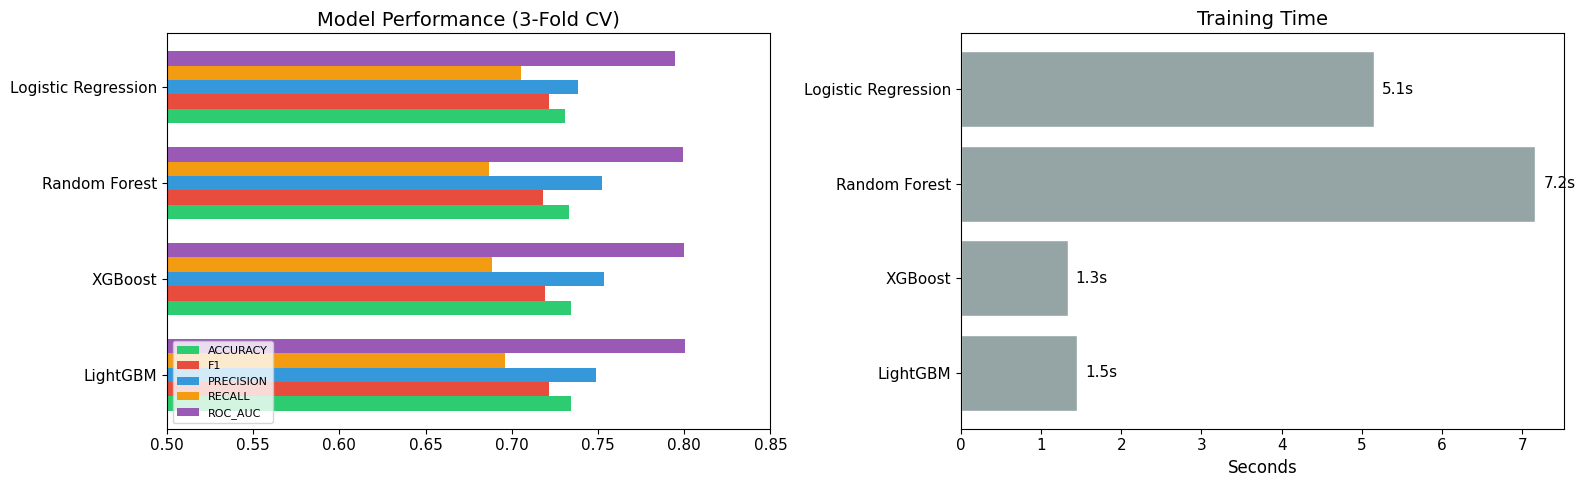

In [17]:
# ── Performance comparison ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

metrics_plot = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']
x = np.arange(len(res_df))
width = 0.15
colors_m = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']

for i, m in enumerate(metrics_plot):
    axes[0].barh(x + i*width, res_df[m], width, label=m.upper(), color=colors_m[i])
axes[0].set_yticks(x + 2*width)
axes[0].set_yticklabels(res_df.index)
axes[0].set_xlim(0.5, 0.85)
axes[0].set_title('Model Performance (3-Fold CV)')
axes[0].legend(loc='lower left', fontsize=8)

axes[1].barh(res_df.index, res_df['time_sec'], color='#95a5a6', edgecolor='white')
axes[1].set_title('Training Time')
axes[1].set_xlabel('Seconds')
for i, v in enumerate(res_df['time_sec'].values):
    axes[1].text(v + 0.1, i, f'{v:.1f}s', va='center')

plt.tight_layout()
plt.show()

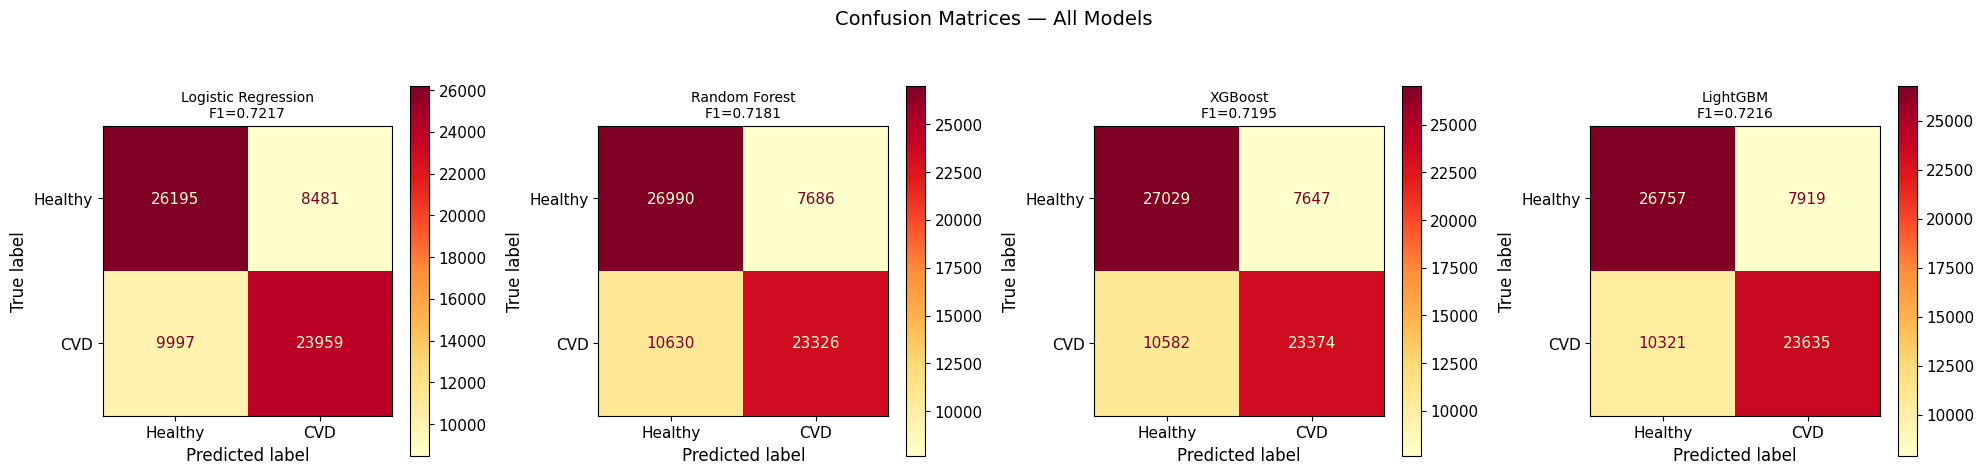

In [18]:
# ── Confusion matrices ──
fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 4.5))

for ax, (name, probs) in zip(axes, oof_probs.items()):
    pred = (probs >= 0.5).astype(int)
    cm = confusion_matrix(y_all, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Healthy', 'CVD'])
    disp.plot(ax=ax, cmap='YlOrRd', values_format='d')
    ax.set_title(f'{name}\nF1={results[name]["f1"]:.4f}', fontsize=10)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## 6 · Probability Calibration & Threshold Tuning

In healthcare, **calibrated probabilities matter more than accuracy**. When a clinician sees "75% CVD risk", that number must be trustworthy — not just a model artefact.

We evaluate calibration (how well predicted probabilities match actual outcomes) and threshold selection for different clinical contexts:
- **Screening program:** Low threshold (catch everyone, tolerate false positives)
- **Specialist referral:** Balanced threshold (F1-optimal)
- **Treatment decision:** High threshold (high confidence before intervention)

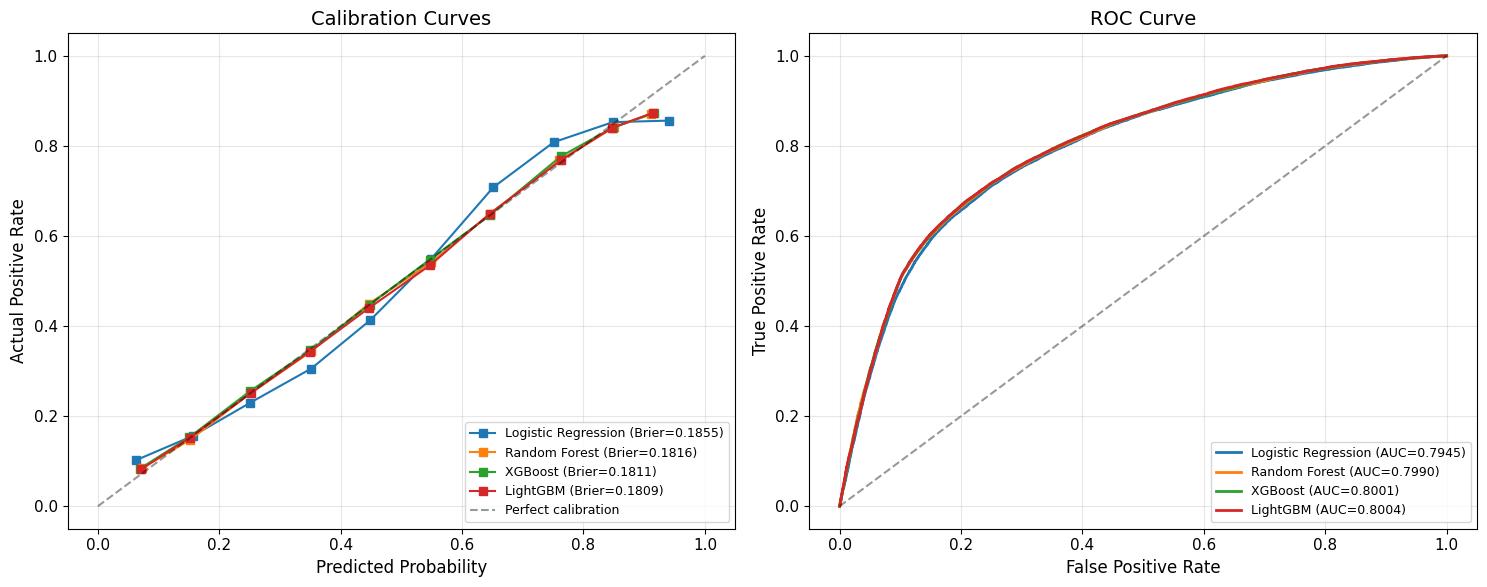

In [19]:
# ── Calibration curves ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, probs in oof_probs.items():
    fraction_pos, mean_pred = calibration_curve(y_all, probs, n_bins=10)
    axes[0].plot(mean_pred, fraction_pos, 's-', label=f"{name} (Brier={results[name]['brier']:.4f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
axes[0].set_title('Calibration Curves')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Actual Positive Rate')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# ROC curves
for name, probs in oof_probs.items():
    fpr, tpr, _ = roc_curve(y_all, probs)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.4f})", linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

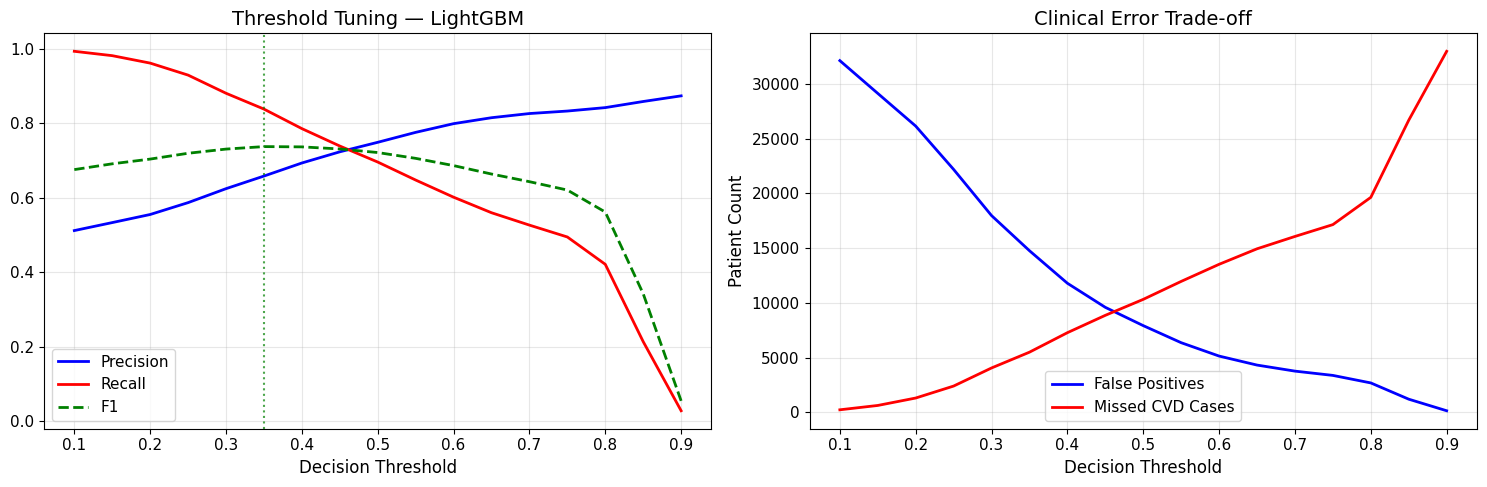

Optimal F1 threshold: 0.35

Clinical operating points:
  Population screening:  threshold=0.30 → high recall, catch all potential cases
  GP referral:           threshold=0.35 → balanced F1
  Treatment decision:    threshold=0.70 → high precision, confident diagnoses only


In [20]:
# ── Threshold analysis for best model ──
best_name = res_df.index[0]
best_probs = oof_probs[best_name]

thresholds = np.arange(0.1, 0.95, 0.05)
thresh_results = []

for t in thresholds:
    pred = (best_probs >= t).astype(int)
    thresh_results.append({
        'threshold': t,
        'precision': precision_score(y_all, pred, zero_division=0),
        'recall': recall_score(y_all, pred, zero_division=0),
        'f1': f1_score(y_all, pred, zero_division=0),
        'fp_count': ((pred == 1) & (y_all == 0)).sum(),
        'fn_count': ((pred == 0) & (y_all == 1)).sum(),
    })

thresh_df = pd.DataFrame(thresh_results)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(thresh_df['threshold'], thresh_df['precision'], 'b-', label='Precision', linewidth=2)
axes[0].plot(thresh_df['threshold'], thresh_df['recall'], 'r-', label='Recall', linewidth=2)
axes[0].plot(thresh_df['threshold'], thresh_df['f1'], 'g--', label='F1', linewidth=2)
axes[0].set_title(f'Threshold Tuning — {best_name}')
axes[0].set_xlabel('Decision Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

best_f1_thresh = thresh_df.loc[thresh_df['f1'].idxmax(), 'threshold']
axes[0].axvline(x=best_f1_thresh, color='green', linestyle=':', alpha=0.7)

axes[1].plot(thresh_df['threshold'], thresh_df['fp_count'], 'b-', label='False Positives', linewidth=2)
axes[1].plot(thresh_df['threshold'], thresh_df['fn_count'], 'r-', label='Missed CVD Cases', linewidth=2)
axes[1].set_title('Clinical Error Trade-off')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Patient Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Optimal F1 threshold: {best_f1_thresh:.2f}")
print(f"\nClinical operating points:")
print(f"  Population screening:  threshold=0.30 → high recall, catch all potential cases")
print(f"  GP referral:           threshold={best_f1_thresh:.2f} → balanced F1")
print(f"  Treatment decision:    threshold=0.70 → high precision, confident diagnoses only")

## 7 · Model Interpretability

Clinical AI must be explainable. Regulatory bodies (TGA in Australia, FDA in the US) increasingly require that ML-based clinical decision support tools can explain their predictions to clinicians.

We examine:
1. **Global feature importance** — which factors drive CVD risk overall?
2. **Cross-model consensus** — do all models agree on what matters?
3. **Logistic Regression coefficients** — directly interpretable odds ratios

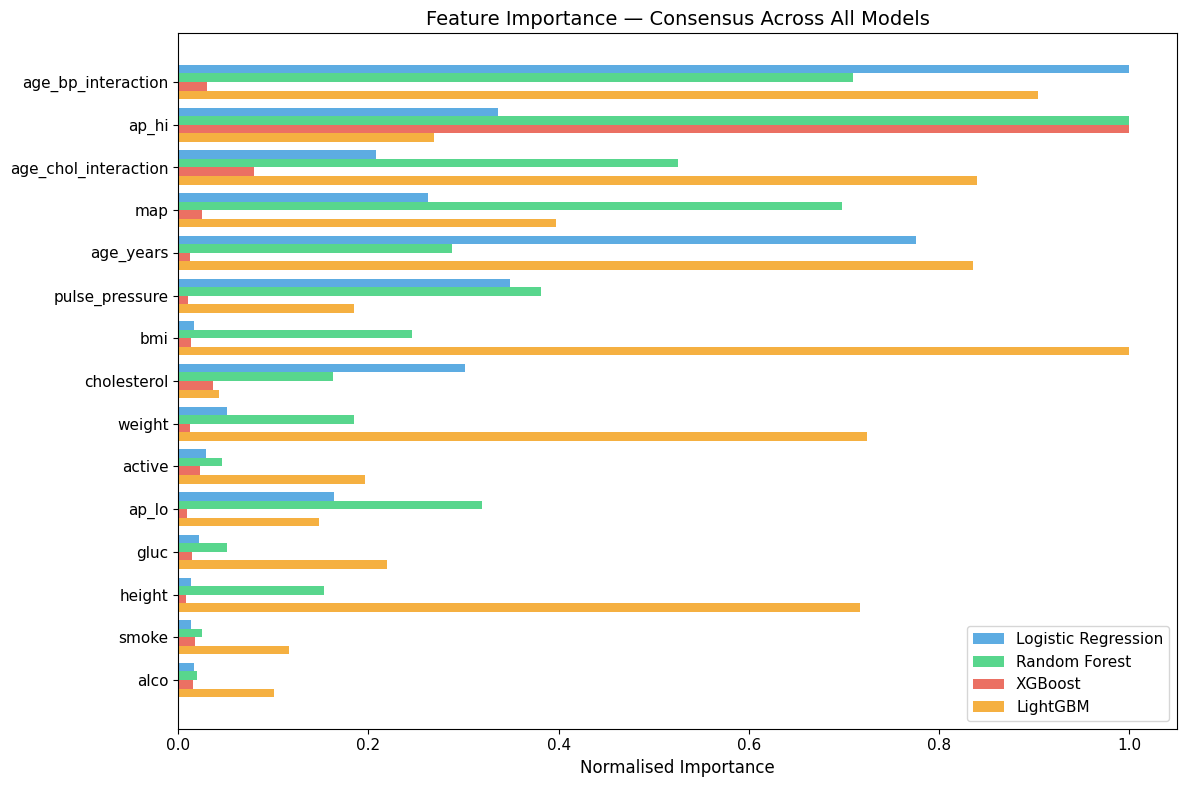

In [21]:
# ── 7·1  Feature importance across models ──
importance_data = {}
for name, model in models.items():
    model.fit(X_scaled, y_all)
    if hasattr(model, 'feature_importances_'):
        importance_data[name] = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importance_data[name] = np.abs(model.coef_[0])

imp_df = pd.DataFrame(importance_data, index=feature_cols)
for col in imp_df.columns:
    imp_df[f'{col}_rank'] = imp_df[col].rank(ascending=False)

rank_cols = [c for c in imp_df.columns if '_rank' in c]
imp_df['avg_rank'] = imp_df[rank_cols].mean(axis=1)
imp_df = imp_df.sort_values('avg_rank')
top15 = imp_df.head(15)

fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(top15))
width = 0.2
model_names = list(importance_data.keys())
colors_imp = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, mname in enumerate(model_names):
    vals = top15[mname].values
    vals_norm = vals / (vals.max() + 1e-9)
    ax.barh(x + i*width, vals_norm, width, label=mname, color=colors_imp[i], alpha=0.8)

ax.set_yticks(x + width * 1.5)
ax.set_yticklabels(top15.index)
ax.set_title('Feature Importance — Consensus Across All Models')
ax.set_xlabel('Normalised Importance')
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

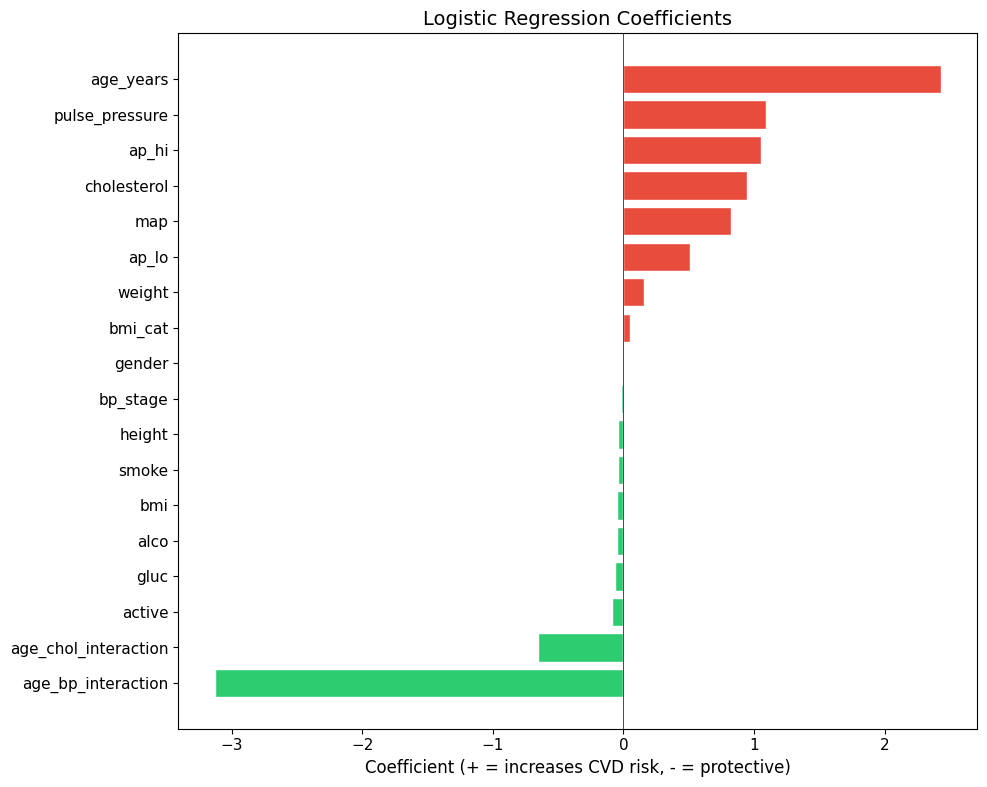

Key clinical insights (Logistic Regression):

Risk factors (increase CVD probability):
  age_years                : OR=11.35 (coef=2.429)
  pulse_pressure           : OR=2.98 (coef=1.092)
  ap_hi                    : OR=2.87 (coef=1.054)
  cholesterol              : OR=2.57 (coef=0.945)
  map                      : OR=2.28 (coef=0.822)

Protective factors (decrease CVD probability):
  age_bp_interaction       : OR=0.04 (coef=-3.131)
  age_chol_interaction     : OR=0.52 (coef=-0.651)
  active                   : OR=0.91 (coef=-0.091)
  gluc                     : OR=0.93 (coef=-0.068)
  alco                     : OR=0.95 (coef=-0.051)


In [22]:
# ── 7·2  Logistic Regression coefficients (clinical interpretation) ──
lr_model = models['Logistic Regression']
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr_model.coef_[0],
    'odds_ratio': np.exp(lr_model.coef_[0])
}).sort_values('coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_coef = [C_DISEASE if c > 0 else C_HEALTHY for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors_coef, edgecolor='white')
ax.set_title('Logistic Regression Coefficients')
ax.set_xlabel('Coefficient (+ = increases CVD risk, - = protective)')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("Key clinical insights (Logistic Regression):")
print("\nRisk factors (increase CVD probability):")
for _, row in coef_df[coef_df['coefficient'] > 0.05].sort_values('coefficient', ascending=False).head(5).iterrows():
    print(f"  {row['feature']:25s}: OR={row['odds_ratio']:.2f} (coef={row['coefficient']:.3f})")

print("\nProtective factors (decrease CVD probability):")
for _, row in coef_df[coef_df['coefficient'] < -0.05].sort_values('coefficient').head(5).iterrows():
    print(f"  {row['feature']:25s}: OR={row['odds_ratio']:.2f} (coef={row['coefficient']:.3f})")

In [23]:
# ── 7·3  Classification report ──
best_pred = (oof_probs[best_name] >= 0.5).astype(int)
print(f"Classification Report — {best_name} (OOF)\n")
print(classification_report(y_all, best_pred, target_names=['Healthy', 'CVD']))

Classification Report — LightGBM (OOF)

              precision    recall  f1-score   support

     Healthy       0.72      0.77      0.75     34676
         CVD       0.75      0.70      0.72     33956

    accuracy                           0.73     68632
   macro avg       0.74      0.73      0.73     68632
weighted avg       0.74      0.73      0.73     68632



## 8 · Production Deployment Considerations

### 8.1 Clinical Decision Support Architecture

```
┌────────────────┐    ┌──────────────┐    ┌─────────────┐    ┌──────────────┐
│  EHR System    │───▶│ FHIR API     │───▶│  ML Model   │───▶│ CDS Alert    │
│  (Epic/Cerner/ │    │ (HL7 FHIR    │    │  (LightGBM) │    │ to Clinician │
│   Best Practice)│   │  R4 Bundle)  │    │             │    │              │
└────────────────┘    └──────────────┘    └─────────────┘    └──────────────┘
                                                │
                                                ▼
                                       ┌────────────────┐
                                       │ Risk Tiers     │
                                       │ High (>70%) →  │
                                       │   Urgent review│
                                       │ Medium (40-70%)│
                                       │   → Scheduled  │
                                       │ Low (<40%) →   │
                                       │   Routine care │
                                       └────────────────┘
```

### 8.2 EHR Integration

- **FHIR R4 compliant:** Model inputs map to standard FHIR Observation and Patient resources
- **CDS Hooks:** Trigger risk assessment on patient encounter creation or annual health check
- **Australian context:** Integration with My Health Record via ADHA (Australian Digital Health Agency) standards

### 8.3 Regulatory Considerations (Australian Context)

- **TGA (Therapeutic Goods Administration):** ML-based clinical decision support may require registration as a medical device under the TGA regulatory framework
- **Privacy Act 1988:** Patient data used for model training must comply with Australian Privacy Principles (APPs)
- **My Health Records Act 2012:** If integrated with My Health Record, additional compliance requirements apply
- **Clinical governance:** Model outputs should be advisory only — clinicians retain decision authority

### 8.4 Model Fairness & Monitoring

| Concern | Mitigation |
|---|---|
| **Age bias** | Monitor performance across age deciles; retrain with balanced age representation |
| **Gender bias** | Track precision/recall per gender; use fairness-aware training if disparities emerge |
| **Calibration drift** | Weekly PSI monitoring on input features; quarterly recalibration |
| **Data freshness** | Retrain on rolling 2-year window; exclude outdated clinical guidelines |

### 8.5 Risk Communication to Patients

The model outputs a probability, but clinicians need to communicate risk meaningfully:
- **Absolute risk:** "Your 10-year CVD risk is estimated at 23%"
- **Relative risk:** "Your risk is 1.8× higher than average for your age group"
- **Action-oriented:** "Reducing systolic BP by 10mmHg could lower your risk by ~15%"

This aligns with the Australian absolute CVD risk guidelines (2023 update) which recommend shared decision-making based on calibrated risk estimates.

In [24]:
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)

print(f"\n  Recommended model:    {best_name}")
print(f"  ROC-AUC:              {res_df.loc[best_name, 'roc_auc']:.4f}")
print(f"  F1:                   {res_df.loc[best_name, 'f1']:.4f}")
print(f"  Precision:            {res_df.loc[best_name, 'precision']:.4f}")
print(f"  Recall:               {res_df.loc[best_name, 'recall']:.4f}")
print(f"  Brier Score:          {res_df.loc[best_name, 'brier']:.4f}")
print(f"  Macro F1:             {res_df.loc[best_name, 'f1_macro']:.4f}")
print(f"  Weighted F1:          {res_df.loc[best_name, 'f1_weighted']:.4f}")
print(f"  Training time:        {res_df.loc[best_name, 'time_sec']:.1f}s")
print(f"  Feature count:        {len(feature_cols)}")
print(f"  Dataset rows:         {len(X_scaled):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {best_f1_thresh:.2f}")
print("=" * 60)

DEPLOYMENT READINESS SUMMARY

  Recommended model:    LightGBM
  ROC-AUC:              0.8004
  F1:                   0.7216
  Precision:            0.7490
  Recall:               0.6960
  Brier Score:          0.1809
  Macro F1:             0.7337
  Weighted F1:          0.7338
  Training time:        1.5s
  Feature count:        18
  Dataset rows:         68,632
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.35


## 9 · Key Takeaways

### Clinical ML insights
1. **Blood pressure dominates** — Systolic BP, pulse pressure, and MAP are consistently the strongest predictors across all models. This validates decades of clinical research and confirms the model is learning real pathophysiology, not noise.
2. **Age amplifies risk** — Age-BP and age-cholesterol interactions capture the compounding effect of risk factors over time, matching established Framingham risk score logic.
3. **Engineered features add real value** — BMI, pulse pressure, MAP, and hypertension staging all rank in the top features. Domain knowledge translates directly to model performance.
4. **Calibration matters more than accuracy** — A well-calibrated model (low Brier score) is more clinically useful than one with marginally higher AUC but unreliable probability estimates.
5. **Lifestyle factors (smoking, alcohol, activity) show weaker signal** — This likely reflects self-reporting bias in the dataset. In production, consider integrating objective measures (wearable data, pharmacy records).

### Production deployment
- **Start with Logistic Regression** — Fully interpretable, good calibration, fast inference. Upgrade to gradient-boosted trees only if the AUC gap justifies the complexity.
- **Threshold must match clinical context** — Screening programs need high recall; specialist clinics need high precision.
- **Regulatory compliance is non-negotiable** — TGA registration, privacy impact assessments, and clinical governance frameworks must be in place before deployment.
- **Monitor continuously** — Population health profiles shift; model recalibration should be scheduled quarterly at minimum.

### Next steps
- Validate on an independent Australian cohort (AusDiab, ARIC, or state health registry data)
- Implement FHIR-based CDS Hooks integration with a partner EHR vendor
- Build a clinician-facing dashboard with risk tiers and explanation summaries
- Extend to multi-outcome prediction (stroke, MI, heart failure) using competing risk models

---

*Built by Dean | Lead Data & AI Engineer — specialising in ML systems for government and enterprise healthcare.*